In [ ]:
import networkx as nx
import pandas as pd
import random
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt

In [ ]:
def read_conllu(file_path):
    sentences = []
    sentence = []

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()

            if line == "":
                if sentence:
                    sentences.append(sentence)
                    sentence = []
            elif not line.startswith("#"):
                parts = line.split("\t")
                if len(parts) >= 7:
                    sentence.append(parts)

    return sentences

In [ ]:
def build_tree(sentence):
    G = nx.DiGraph()

    for token in sentence:
        if "-" in token[0] or "." in token[0]:
            continue

        try:
            idx = int(token[0])
            head = int(token[6])
        except:
            continue

        G.add_node(idx)

        if head != 0:
            G.add_edge(head, idx)

    return G

In [ ]:
def load_trees(file_path):
    sentences = read_conllu(file_path)
    trees = []

    for sent in sentences:
        if len(sent) > 1:
            tree = build_tree(sent)
            if len(tree.nodes) > 1:
                trees.append(tree)

    return trees

In [ ]:
def compute_depth(tree):
    if len(tree.nodes) == 0:
        return 0

    try:
        return nx.dag_longest_path_length(tree)
    except:
        return 0

In [ ]:
def compute_arity(tree):
    if len(tree.nodes) == 0:
        return 0

    total_children = 0

    for node in tree.nodes:
        total_children += tree.out_degree(node)

    return total_children / len(tree.nodes)

In [ ]:
def compute_density(tree):
    n = len(tree.nodes)

    if n <= 1:
        return 0

    edges = len(tree.edges)
    max_edges = n * (n - 1)

    return edges / max_edges

In [ ]:
def generate_random_tree(n):
    G = nx.DiGraph()
    nodes = list(range(1, n + 1))

    for node in nodes:
        G.add_node(node)

    for node in nodes[1:]:
        parent = random.choice(nodes[:node-1])
        G.add_edge(parent, node)

    return G

In [ ]:
def build_dataset(trees):
    data = []

    for tree in trees:
        n = len(tree.nodes)

        # Natural
        data.append({
            "type": "natural",
            "depth": compute_depth(tree),
            "arity": compute_arity(tree),
            "density": compute_density(tree)
        })

        # Random
        rand_tree = generate_random_tree(n)

        data.append({
            "type": "random",
            "depth": compute_depth(rand_tree),
            "arity": compute_arity(rand_tree),
            "density": compute_density(rand_tree)
        })

    return pd.DataFrame(data)

In [ ]:
def run_analysis(df):
    results = {}

    for metric in ["depth", "arity", "density"]:
        natural = df[df["type"] == "natural"][metric]
        random_vals = df[df["type"] == "random"][metric]

        t_stat, p_val = ttest_ind(natural, random_vals)

        results[metric] = {
            "natural_mean": natural.mean(),
            "random_mean": random_vals.mean(),
            "p_value": p_val
        }

    # Clean formatted output
    print("=" * 45)
    print("        STATISTICAL ANALYSIS RESULTS")
    print("=" * 45)
    for metric, vals in results.items():
        p = vals['p_value']
        if p < 0.001:
            sig = "*** (highly significant)"
        elif p < 0.01:
            sig = "**  (very significant)"
        elif p < 0.05:
            sig = "*   (significant)"
        else:
            sig = "    (not significant)"

        print(f"\n  Metric       : {metric.upper()}")
        print(f"  Natural Mean : {vals['natural_mean']:.4f}")
        print(f"  Random Mean  : {vals['random_mean']:.4f}")
        print(f"  p-value      : {p:.4e}  {sig}")
    print("\n" + "=" * 45)

    return results

In [ ]:
def plot_results(df):
    for metric in ["depth", "arity", "density"]:
        natural = df[df["type"] == "natural"][metric]
        random_vals = df[df["type"] == "random"][metric]

        # Histogram
        plt.figure(figsize=(8, 5))
        plt.hist(natural, alpha=0.5, label="Natural", color="steelblue")
        plt.hist(random_vals, alpha=0.5, label="Random", color="orange")
        plt.title(f"{metric.capitalize()} Distribution: Natural vs Random")
        plt.xlabel(metric.capitalize())
        plt.ylabel("Frequency")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Boxplot
        plt.figure(figsize=(7, 5))
        plt.boxplot([natural, random_vals], labels=["Natural", "Random"])
        plt.title(f"{metric.capitalize()} Boxplot: Natural vs Random")
        plt.ylabel(metric.capitalize())
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.show()

In [ ]:
import os
print(os.listdir())

['.config', 'final_sud_table.png', 'depth_Japanese.png', 'depth_Hindi.png', 'depth_French.png', 'depth_English.png', 'language_stats.csv', 'depth_Spanish.png', 'depth_Turkish.png', 'depth_Arabic.png', 'depth_Russian.png', 'depth_Chinese.png', 'depth_German.png', 'dataset_english.csv', 'drive', 'sample_data']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['WhatsApp Image 2022-01-29 at 10.37.48.jpeg', 'Chrome Syncable FileSystem', 'Reports', 'IMG20230907003504.jpg', 'Snapchat-649209438.jpg', 'Portfolio.gsite', 'Colab Notebooks', 'HimanshuRana _240454', 'reciept', 'Photos', 'Kos bakchodi', 'es_pud-sud-test.conllu', 'en_pronouns-sud-test.conllu', 'ru_pud-sud-test.conllu', 'fr_pud-sud-test.conllu', 'hi_pud-sud-test.conllu', 'ja_pudluw-sud-test.conllu', 'tr_pud-sud-test.conllu', 'de_pud-sud-test.conllu', 'ar_pud-sud-test.conllu', 'chinese-beginner.A1.SUD.conllu', 'speech.gdoc', 'hindi speech.gdoc', '49fe50f27f8541e087ef19645560834f.MP4', 'https: youtube.com shorts _z1FbBcP85o?si=e7yH163eLb9bfRK0.txt', 'resume_final.pdf', 'theme.gdoc', 'Himanshu Rana (240454).gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'resume', 'ECO231 Assignment .gdoc', 'Project_2.gdoc', 'SUD_Chinese-Beginner.tar', 'SUD_Arabic-PUD.tar', 'SUD_French-PUD.tar', 'SUD_German-PUD.tar', 'SUD_French-GSD.tgz.download.zip', 'SUD_Hindi-PUD.tar', 'SUD_Russian-PUD.ta

In [ ]:
files = {
    "English": "/content/drive/MyDrive/en_pronouns-sud-test.conllu",
    "Hindi": "/content/drive/MyDrive/hi_pud-sud-test.conllu",
    "French": "/content/drive/MyDrive/fr_pud-sud-test.conllu",
    "Spanish": "/content/drive/MyDrive/es_pud-sud-test.conllu",
    "German": "/content/drive/MyDrive/de_pud-sud-test.conllu",
    "Japanese": "/content/drive/MyDrive/ja_pudluw-sud-test.conllu",
    "Russian": "/content/drive/MyDrive/ru_pud-sud-test.conllu",
    "Arabic": "/content/drive/MyDrive/ar_pud-sud-test.conllu",
    "Chinese": "/content/drive/MyDrive/chinese-beginner.A1.SUD.conllu",
    "Turkish": "/content/drive/MyDrive/tr_pud-sud-test.conllu",

}

Trees loaded: 285
        STATISTICAL ANALYSIS RESULTS

  Metric       : DEPTH
  Natural Mean : 1.9649
  Random Mean  : 2.6596
  p-value      : 3.4027e-21  *** (highly significant)

  Metric       : ARITY
  Natural Mean : 0.8168
  Random Mean  : 0.8168
  p-value      : 1.0000e+00      (not significant)

  Metric       : DENSITY
  Natural Mean : 0.1832
  Random Mean  : 0.1832
  p-value      : 1.0000e+00      (not significant)

{'depth': {'natural_mean': np.float64(1.9649122807017543), 'random_mean': np.float64(2.6596491228070174), 'p_value': np.float64(3.402705763044577e-21)}, 'arity': {'natural_mean': np.float64(0.8167780562517405), 'random_mean': np.float64(0.8167780562517405), 'p_value': np.float64(1.0)}, 'density': {'natural_mean': np.float64(0.18322194374825956), 'random_mean': np.float64(0.18322194374825956), 'p_value': np.float64(1.0)}}


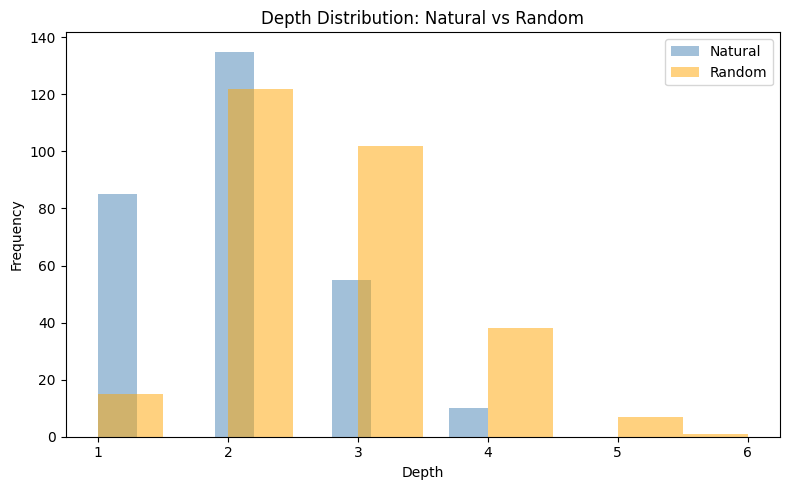

/tmp/ipykernel_9443/54862743.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([natural, random_vals], labels=["Natural", "Random"])


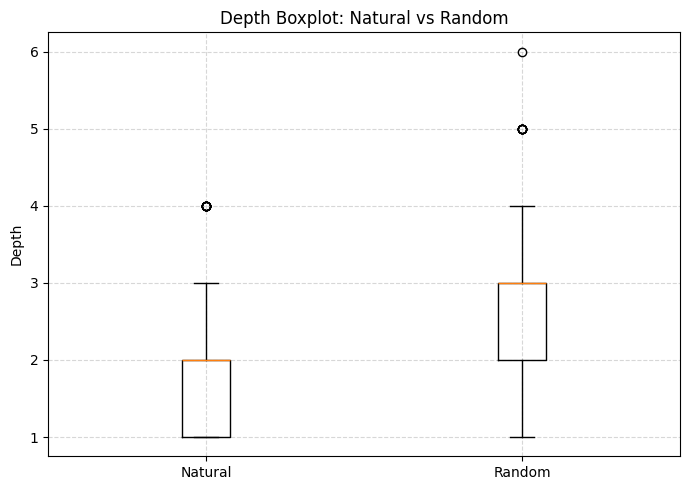

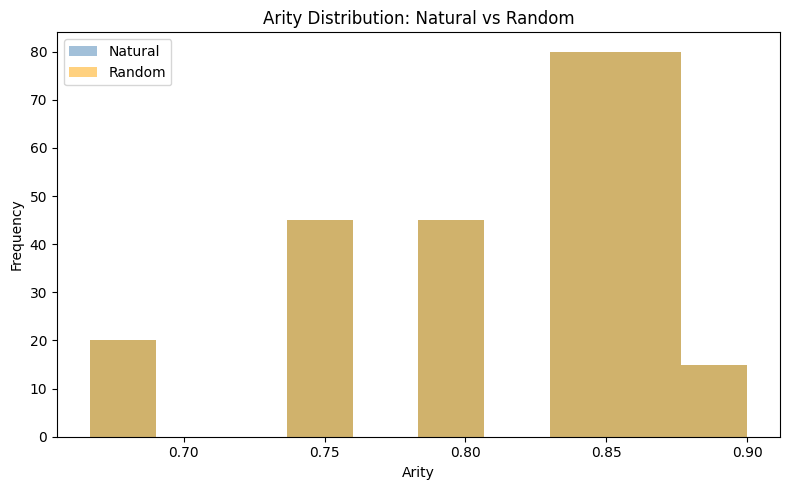

/tmp/ipykernel_9443/54862743.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([natural, random_vals], labels=["Natural", "Random"])


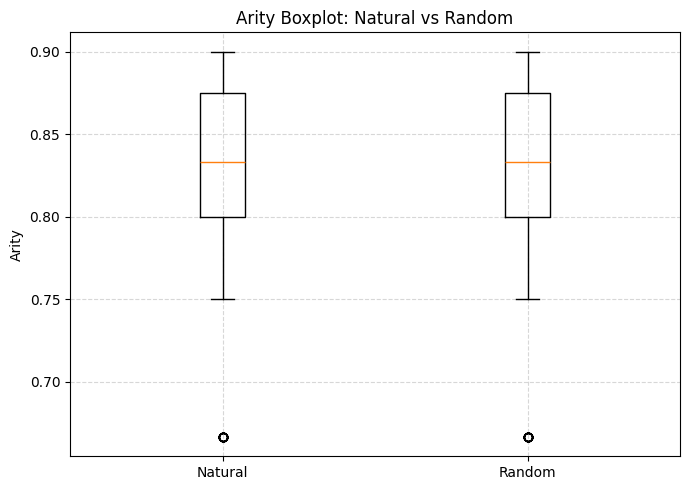

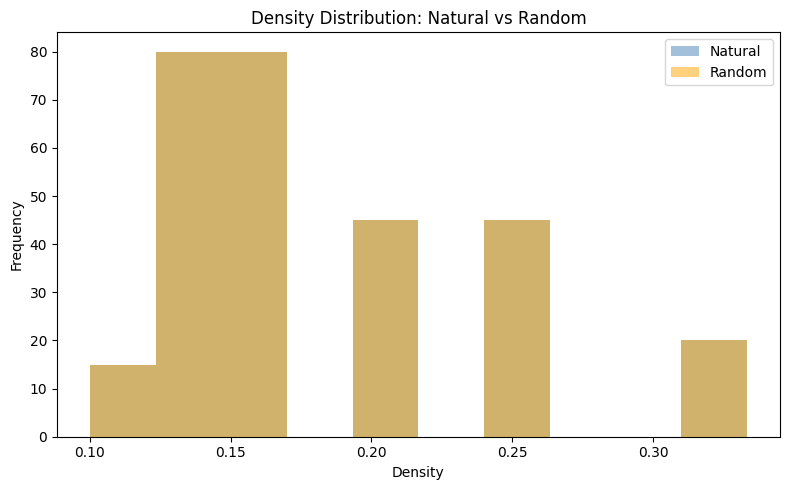

/tmp/ipykernel_9443/54862743.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([natural, random_vals], labels=["Natural", "Random"])


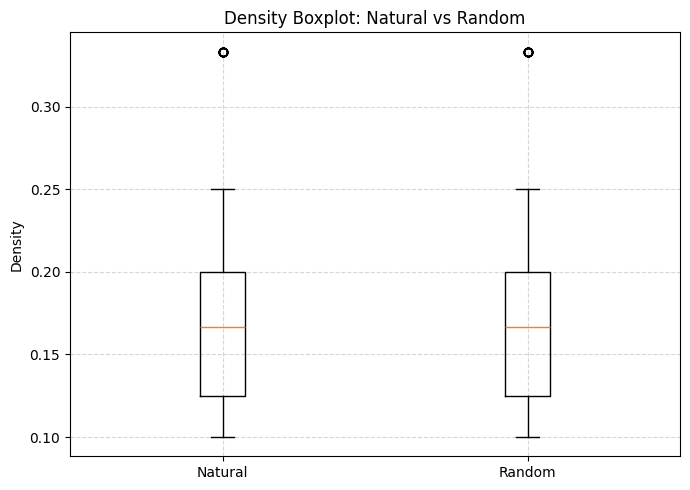

In [ ]:
file_path = "/content/drive/MyDrive/en_pronouns-sud-test.conllu"
trees = load_trees(file_path)
print("Trees loaded:", len(trees))

df = build_dataset(trees)

results = run_analysis(df)
print(results)

plot_results(df)

In [ ]:
all_data = []

for lang, path in files.items():
    trees = load_trees(path)

    for tree in trees:
        n = len(tree.nodes)

        # Natural
        all_data.append({
            "language": lang,
            "type": "natural",
            "depth": compute_depth(tree),
            "arity": compute_arity(tree),
            "density": compute_density(tree)
        })

        # Random
        rand_tree = generate_random_tree(n)

        all_data.append({
            "language": lang,
            "type": "random",
            "depth": compute_depth(rand_tree),
            "arity": compute_arity(rand_tree),
            "density": compute_density(rand_tree)
        })

In [ ]:
df = pd.DataFrame(all_data)

In [ ]:
stats = df.groupby(["language", "type"]).agg({
    "depth": "mean",
    "arity": "mean",
    "density": "mean"
}).reset_index()

print(stats)

    language     type     depth     arity   density
0     Arabic  natural  6.554000  0.940709  0.059291
1     Arabic   random  4.907000  0.940709  0.059291
2    Chinese  natural  2.213068  0.824468  0.175532
3    Chinese   random  2.735795  0.824468  0.175532
4    English  natural  1.964912  0.816778  0.183222
5    English   random  2.642105  0.816778  0.183222
6     French  natural  7.013000  0.951031  0.048969
7     French   random  5.247000  0.951031  0.048969
8     German  natural  5.894000  0.943281  0.056719
9     German   random  4.919000  0.943281  0.056719
10     Hindi  natural  7.232000  0.949309  0.050691
11     Hindi   random  5.246000  0.949309  0.050691
12  Japanese  natural  8.715000  0.948248  0.051752
13  Japanese   random  5.105000  0.948248  0.051752
14   Russian  natural  5.658000  0.936656  0.063344
15   Russian   random  4.755000  0.936656  0.063344
16   Spanish  natural  6.662000  0.947601  0.052399
17   Spanish   random  5.148000  0.947601  0.052399
18   Turkish

In [ ]:
pivot_table = stats.pivot(index="language", columns="type")
print(pivot_table)

             depth               arity             density          
type       natural    random   natural    random   natural    random
language                                                            
Arabic    6.554000  4.907000  0.940709  0.940709  0.059291  0.059291
Chinese   2.213068  2.735795  0.824468  0.824468  0.175532  0.175532
English   1.964912  2.642105  0.816778  0.816778  0.183222  0.183222
French    7.013000  5.247000  0.951031  0.951031  0.048969  0.048969
German    5.894000  4.919000  0.943281  0.943281  0.056719  0.056719
Hindi     7.232000  5.246000  0.949309  0.949309  0.050691  0.050691
Japanese  8.715000  5.105000  0.948248  0.948248  0.051752  0.051752
Russian   5.658000  4.755000  0.936656  0.936656  0.063344  0.063344
Spanish   6.662000  5.148000  0.947601  0.947601  0.052399  0.052399
Turkish   4.973000  4.448000  0.928992  0.928992  0.071008  0.071008


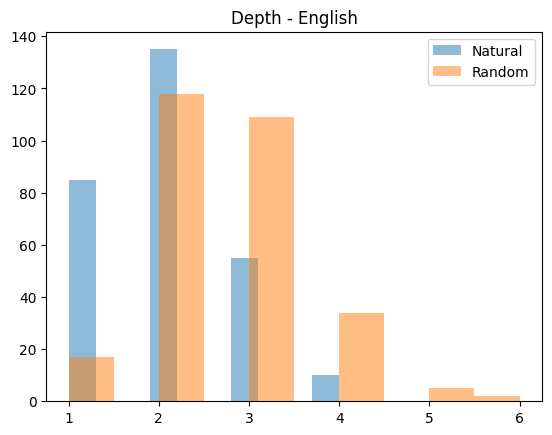

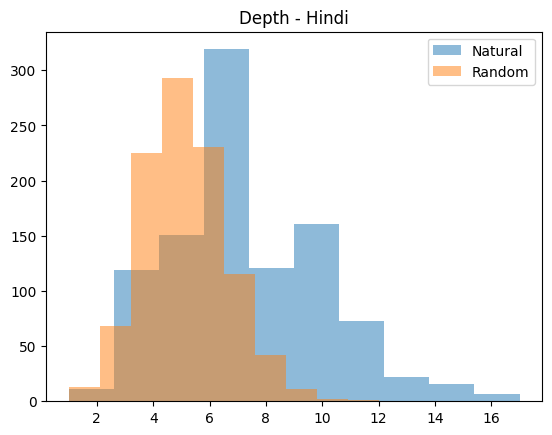

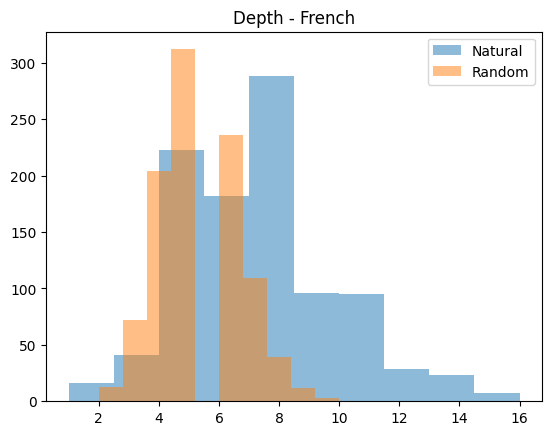

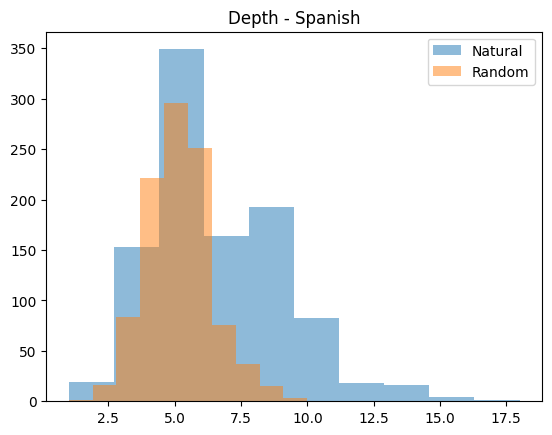

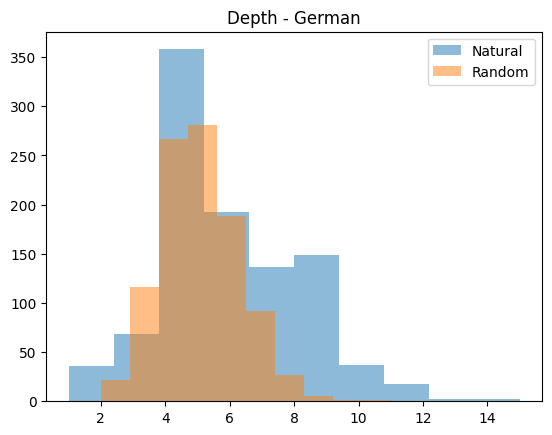

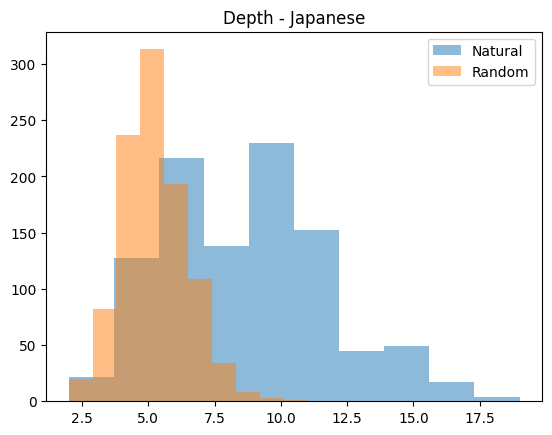

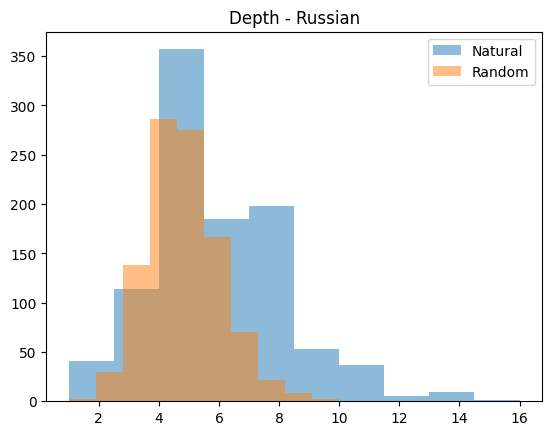

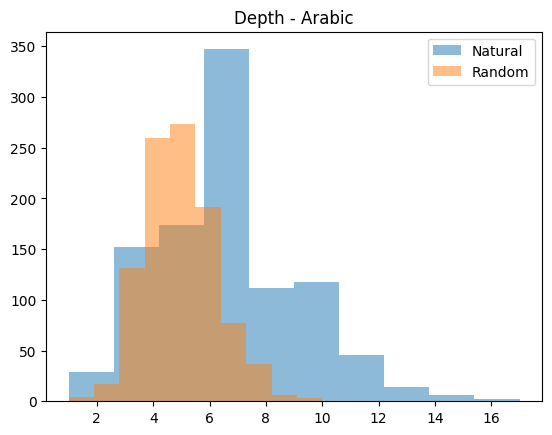

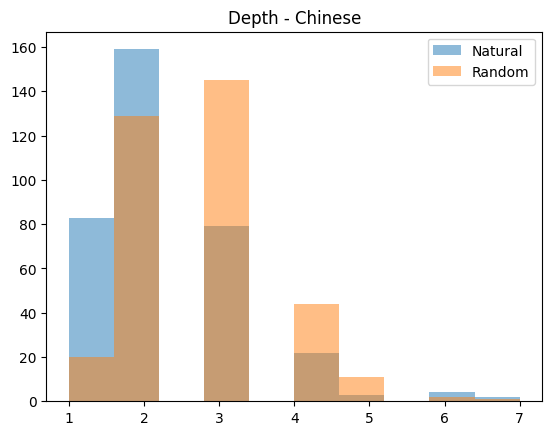

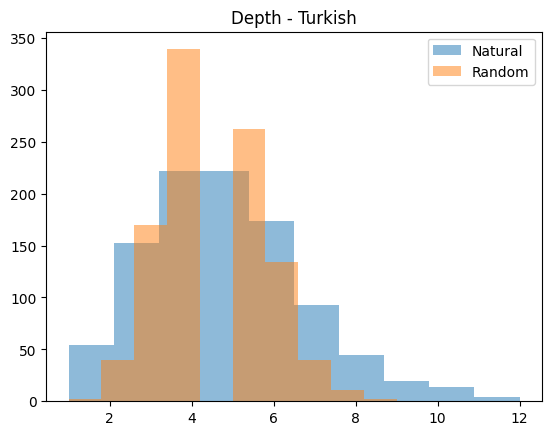

In [ ]:
for lang in df["language"].unique():
    subset = df[df["language"] == lang]

    plt.figure()

    natural = subset[subset["type"] == "natural"]["depth"]
    random_vals = subset[subset["type"] == "random"]["depth"]

    plt.hist(natural, alpha=0.5, label="Natural")
    plt.hist(random_vals, alpha=0.5, label="Random")

    plt.title(f"Depth - {lang}")
    plt.legend()


    filename = f"depth_{lang}.png"
    plt.savefig(filename)

    plt.show()

In [ ]:
df.to_csv("dataset_english.csv", index=False)

In [ ]:
stats.to_csv("language_stats.csv", index=False)

In [ ]:
import os
print(os.listdir("/content/drive/MyDrive"))

['WhatsApp Image 2022-01-29 at 10.37.48.jpeg', 'Chrome Syncable FileSystem', 'Reports', 'IMG20230907003504.jpg', 'Snapchat-649209438.jpg', 'Portfolio.gsite', 'Colab Notebooks', 'HimanshuRana _240454', 'reciept', 'Photos', 'Kos bakchodi', 'es_pud-sud-test.conllu', 'en_pronouns-sud-test.conllu', 'ru_pud-sud-test.conllu', 'fr_pud-sud-test.conllu', 'hi_pud-sud-test.conllu', 'ja_pudluw-sud-test.conllu', 'tr_pud-sud-test.conllu', 'de_pud-sud-test.conllu', 'ar_pud-sud-test.conllu', 'chinese-beginner.A1.SUD.conllu', 'speech.gdoc', 'hindi speech.gdoc', '49fe50f27f8541e087ef19645560834f.MP4', 'https: youtube.com shorts _z1FbBcP85o?si=e7yH163eLb9bfRK0.txt', 'resume_final.pdf', 'theme.gdoc', 'Himanshu Rana (240454).gdoc', 'Untitled document (1).gdoc', 'Untitled document.gdoc', 'resume', 'ECO231 Assignment .gdoc', 'Project_2.gdoc', 'SUD_Chinese-Beginner.tar', 'SUD_Arabic-PUD.tar', 'SUD_French-PUD.tar', 'SUD_German-PUD.tar', 'SUD_French-GSD.tgz.download.zip', 'SUD_Hindi-PUD.tar', 'SUD_Russian-PUD.ta

In [ ]:
treebank_ids = {
    "Arabic": "SUD_Arabic-PUD",
    "Chinese": "SUD_Chinese-Beginner",
    "French": "SUD_French-PUD",
    "German": "SUD_German-PUD",
    "Hindi": "SUD_Hindi-PUD",
    "Japanese": "SUD_Japanese-PUDLUW",
    "Russian": "SUD_Russian-PUD",
    "Spanish": "SUD_Spanish-PUD",
    "Turkish": "SUD_Turkish-PUD",
    "English": "SUD_English-PUD"
}

In [ ]:
def get_stats(file_path):
    sentences = 0
    tokens = 0

    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            if line.strip() == "":
                sentences += 1
            elif not line.startswith("#"):
                parts = line.split("\t")
                if len(parts) > 0 and "-" not in parts[0] and "." not in parts[0]:
                    tokens += 1

    return sentences, tokens


data = []

for lang, file in files.items():
    s, t = get_stats(file)
    data.append([lang, treebank_ids[lang], s, t])
# Convert to dataframe
import pandas as pd

df = pd.DataFrame(data, columns=["Language", "SUD Treebank ID", "Sentences", "Tokens"])

# Add total row
total_row = pd.DataFrame([[
    "Total",
    "",
    df["Sentences"].sum(),
    df["Tokens"].sum()
]], columns=df.columns)

df = pd.concat([df, total_row], ignore_index=True)

df

,Language,SUD Treebank ID,Sentences,Tokens
0,English,SUD_English-PUD,285,1705
1,Hindi,SUD_Hindi-PUD,1000,23829
2,French,SUD_French-PUD,1000,24726
3,Spanish,SUD_Spanish-PUD,1000,23283
4,German,SUD_German-PUD,1000,21332
5,Japanese,SUD_Japanese-PUDLUW,1000,22910
6,Russian,SUD_Russian-PUD,1000,19355
7,Arabic,SUD_Arabic-PUD,1000,20747
8,Chinese,SUD_Chinese-Beginner,352,2234
9,Turkish,SUD_Turkish-PUD,1000,16881


In [ ]:
df["Sentences"] = df["Sentences"].map(lambda x: f"{x:,}")
df["Tokens"] = df["Tokens"].map(lambda x: f"{x:,}")

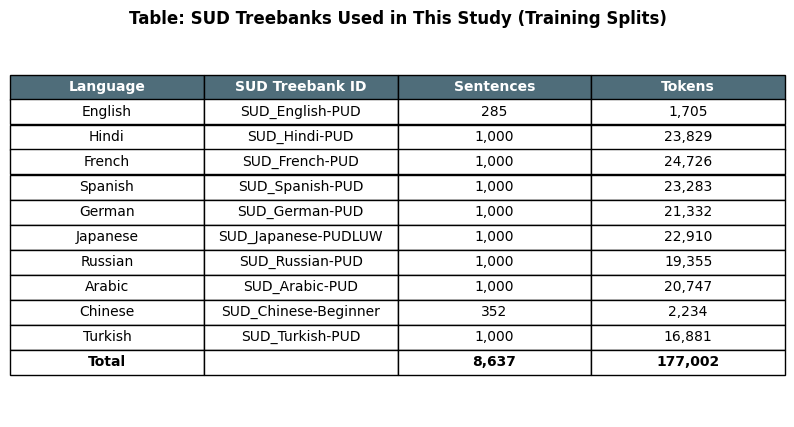

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('off')

table = ax.table(
    cellText=df.values,
    colLabels=df.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Style header
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_text_props(weight='bold')
        cell.set_facecolor('#4F6D7A')   # dark header like your sample
        cell.set_text_props(color='white')
    elif row == len(df):  # total row
        cell.set_text_props(weight='bold')

plt.title("Table: SUD Treebanks Used in This Study (Training Splits)", fontsize=12, weight='bold')

plt.savefig("final_sud_table.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
from google.colab import files
files.download("final_sud_table.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(files.keys())
print(treebank_ids.keys())

dict_keys(['English', 'Hindi', 'French', 'Spanish', 'German', 'Japanese', 'Russian', 'Arabic', 'Chinese', 'Turkish'])
dict_keys(['Arabic', 'Chinese', 'French', 'German', 'Hindi', 'Japanese', 'Russian', 'Spanish', 'Turkish'])
